# Dipole mask

In [1]:
import fitsio
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, MaskedColumn
import pyccl as ccl
from ulid import ULID

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [2]:
#resolution:
nside = 128
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 196608
Total number of sources in the entire sky : 196608000000
Theorical number of sources in one pixel : 1000000


## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.528e-08 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 5.53e-08 (Goal: 0.0002)    │            time = 7.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.7000   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 1 │ ra   │   264.0   │    0.1    │    -0.1    │    0.1     │    0    │   360   │       │
│ 2 │ dec  │   48.00   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0027  │  0.0027   │   -0.1    │    0.1    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 7.12e-06    -0e-6    -0e-6 │
│  ra │    -0e-6   0.0104    0.000 │
│ dec │    -0e-6    0.000  0.00412 │
└─────┴────────────────────────────┘

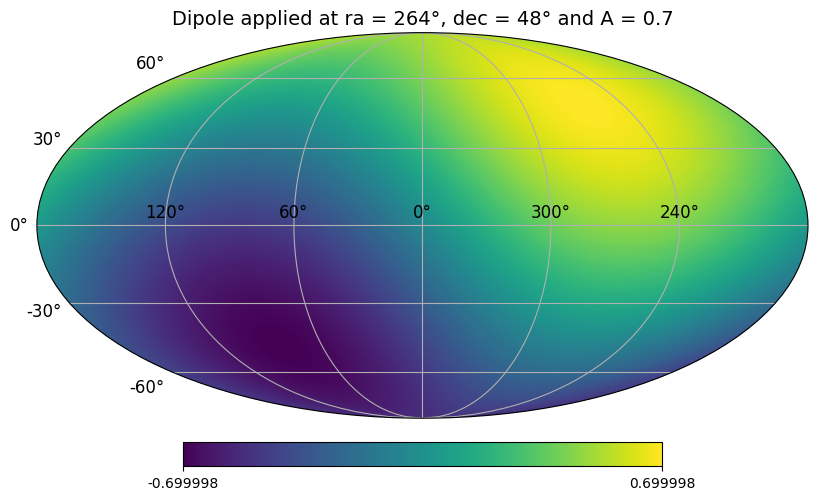

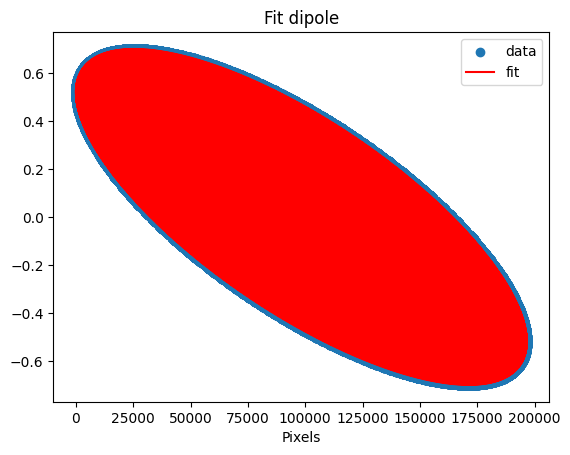

In [7]:
nest = False
A, raD, decD = 0.7, 264, 48
NSource_px_dipole = apply_dipole_ARaDec(np.arange(npix), A, raD, decD, nest)
hp.projview(NSource_px_dipole, title=f"Dipole applied at ra = {raD}°, dec = {decD}° and A = {A}", graticule=True, graticule_labels=True)

model = lambda map, A, ra, dec : apply_dipole_ARaDec(map, A, ra, dec, nest=nest)
init =  (1, 100, 40)
names = ("A", "ra", "dec")
NSource_px_dipole[NSource_px_dipole == 0] = np.nan
m = fit_dipole_err(model, NSource_px_dipole, init, names, bounds=([0, 0, -90], [1, 360, 90]))
m

## Mask creation

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.81e-05 (χ²/ndof = 0.0)   │              Nfcn = 251              │
│ EDM = 1.81e-05 (Goal: 0.0002)    │            time = 7.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.7000   │  0.0029   │  -0.0028   │   0.0029   │    0    │    1    │       │
│ 1 │ ra   │  264.00   │   0.11    │   -0.11    │    0.11    │    0    │   360   │       │
│ 2 │ dec  │   48.00   │   0.08    │   -0.08    │    0.08    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0028  │  0.0029   │   -0.11   │   0.11    │   -0.08   │   0.08    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 8.17e-06     3e-6     6e-6 │
│  ra │     3e-6   0.0122    0.002 │
│ dec │     6e-6    0.002  0.00707 │
└─────┴────────────────────────────┘

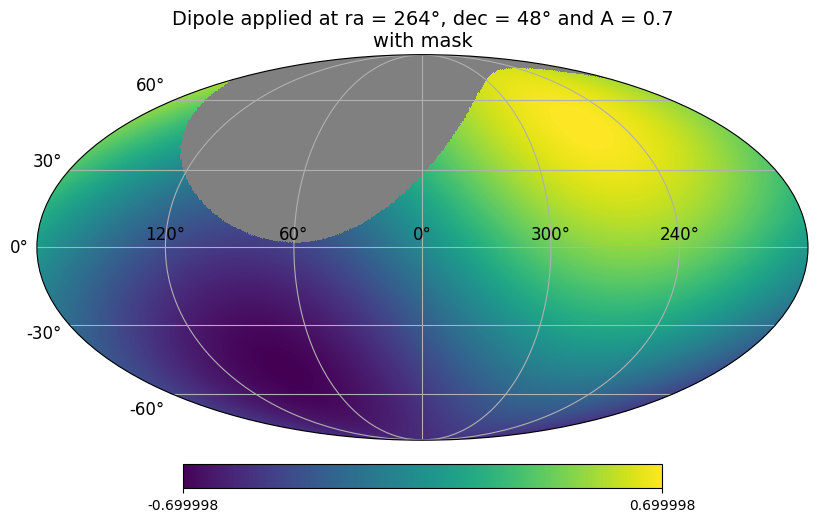

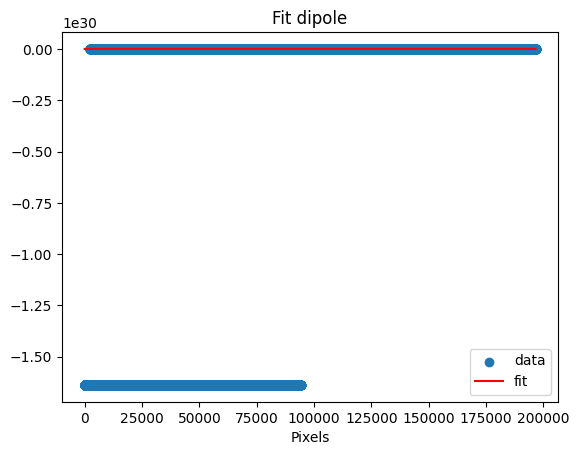

In [8]:
def get_mask_disk(nside, RA, DEC, radius):
    vec = hp.ang2vec(RA, DEC, lonlat=True)
    npix = hp.nside2npix(nside)
    ipix = hp.query_disc(nside=nside, vec=vec, radius=radius)
    mask = np.array([False]*npix)
    mask[ipix] = True
    return mask


def mask2weights(mask, invert=False):
    if not invert: mask = ~mask #is masked if mask == True
    weights = mask.astype(float)
    return weights


mask = get_mask_disk(nside, 60, 52, np.radians(50))
NSource_px_dipole_masked = hp.ma(NSource_px_dipole)
NSource_px_dipole_masked.mask = mask
hp.projview(NSource_px_dipole_masked, title=f"Dipole applied at ra = {raD}°, dec = {decD}° and A = {A}\nwith mask", graticule=True, graticule_labels=True)

weights = mask2weights(mask)
model = lambda map, A, ra, dec : apply_dipole_ARaDec(map, A, ra, dec, nest=nest, cut_masked=True)
init =  (1, 100, 40)
names = ("A", "ra", "dec")
m = fit_dipole_err(model, NSource_px_dipole_masked.filled(), init, names, bounds=([0, 0, -90], [1, 360, 90]), weights=weights)
m

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.88e-08 (χ²/ndof = 0.0)   │              Nfcn = 254              │
│ EDM = 3.88e-08 (Goal: 0.0002)    │            time = 7.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.700   │   0.004   │   -0.004   │   0.004    │    0    │    1    │       │
│ 1 │ ra   │  264.00   │   0.16    │   -0.16    │    0.16    │    0    │   360   │       │
│ 2 │ dec  │   48.00   │   0.11    │   -0.11    │    0.11    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.004   │   0.004   │   -0.16   │   0.16    │   -0.11   │   0.11    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬───────────────────────────────┐
│     │         A        ra       dec │
├─────┼───────────────────────────────┤
│   A │  1.67e-05  0.029e-3 -0.009e-3 │
│  ra │  0.029e-3    0.0251     0.004 │
│ dec │ -0.009e-3     0.004    0.0119 │
└─────┴───────────────────────────────┘

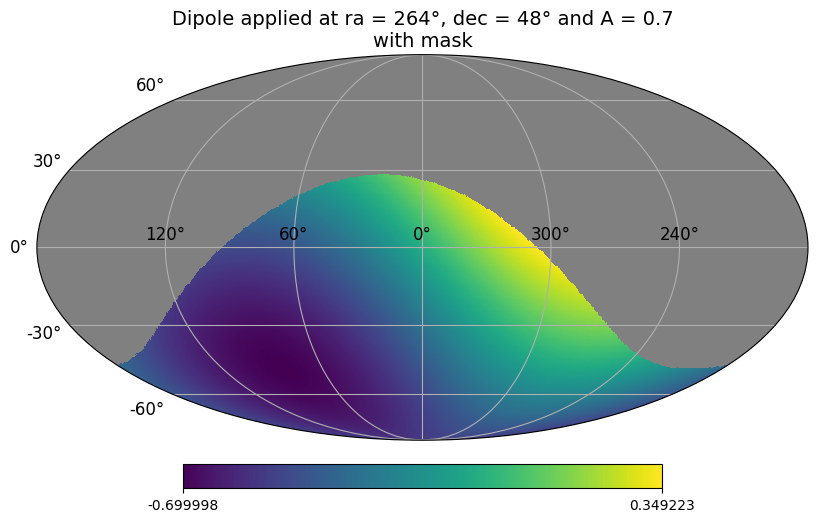

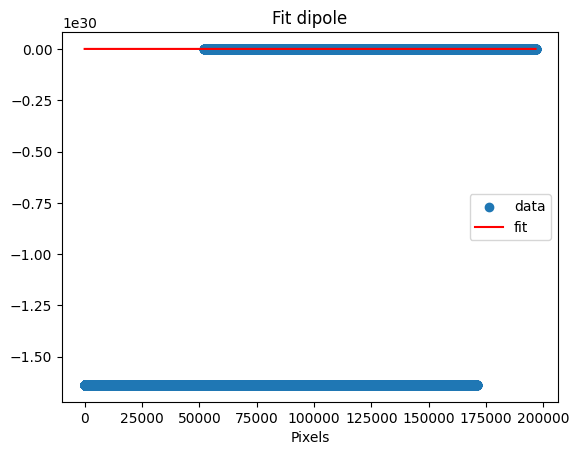

In [6]:
mask = get_mask_disk(nside, 200, 52, np.radians(100))
NSource_px_dipole_masked = hp.ma(NSource_px_dipole)
NSource_px_dipole_masked.mask = mask
hp.projview(NSource_px_dipole_masked, title=f"Dipole applied at ra = {raD}°, dec = {decD}° and A = {A}\nwith mask", graticule=True, graticule_labels=True)

weights = mask2weights(mask)
model = lambda map, A, ra, dec : apply_dipole_ARaDec(map, A, ra, dec, nest=nest, cut_masked=True)
init =  (1, 100, 40)
names = ("A", "ra", "dec")
m = fit_dipole_err(model, NSource_px_dipole_masked.filled(), init, names, bounds=([0, 0, -90], [1, 360, 90]), weights=weights)
m

### From FRACCOV DESI

In [23]:
#File name:
DIR = "../data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-bright.fits"

#Reading file:
DR1 = Table.read(FILE_DR1)
col_ipix = f'HealPIX_{nside}'
DR1[col_ipix] = hp.ang2pix(nside, DR1['RA'], DR1['DEC'], nest=False, lonlat=True)
DR1

HPXPIXEL,RA,DEC,TILEIDS,EXPFACS,NPASS,EXPFAC_MEAN,NTILE,FRACCOV,HealPIX_128
int64,float64,float64,int64[4],float64[4],int64,float64,float64,float64,int64
0,45.0,0.03730194242227469,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
1,45.04394531249999,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
2,44.9560546875,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
3,45.0,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
4,45.08789062499999,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
5,45.13183593749999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
6,45.04394531249999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
7,45.08789062499999,0.18651002832535823,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600
8,44.912109375,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,97600


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.262e-05 (χ²/ndof = 0.0)  │              Nfcn = 448              │
│ EDM = 3.26e-05 (Goal: 0.0002)    │           time = 13.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.700   │   0.005   │   -0.005   │   0.005    │    0    │  4000   │       │
│ 1 │ ra   │  264.00   │   0.13    │   -0.13    │    0.13    │    0    │   360   │       │
│ 2 │ dec  │   48.00   │   0.14    │   -0.14    │    0.14    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.005   │   0.005   │   -0.13   │   0.13    │   -0.14   │   0.14    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 2.16e-05 0.065e-3 0.037e-3 │
│  ra │ 0.065e-3    0.018    0.004 │
│ dec │ 0.037e-3    0.004   0.0203 │
└─────┴────────────────────────────┘

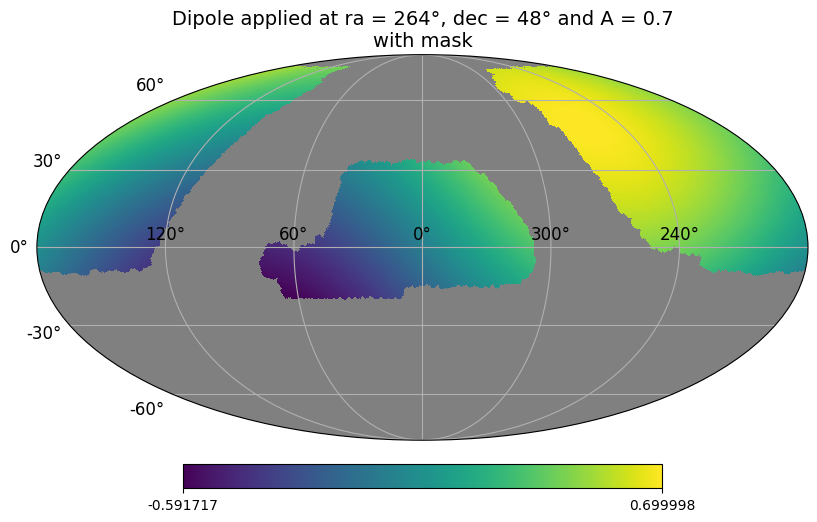

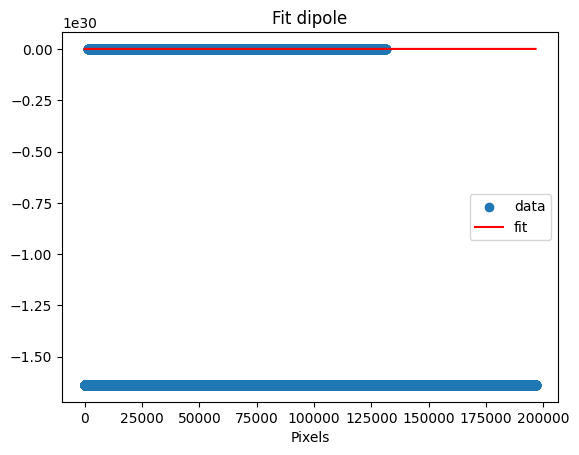

In [24]:
df = DR1[[col_ipix, 'FRACCOV']].to_pandas() # On ne prend que la colonne utile
df['is_masked'] = DR1['FRACCOV'].mask
final_status = df.groupby(col_ipix)['is_masked'].all()
mask = np.array(final_status)
NSource_px_dipole_masked.mask = mask
hp.projview(NSource_px_dipole_masked, title=f"Dipole applied at ra = {raD}°, dec = {decD}° and A = {A}\nwith mask", graticule=True, graticule_labels=True)

weights = mask2weights(mask)
model = lambda map, A, ra, dec : apply_dipole_ARaDec(map, A, ra, dec, nest=nest, cut_masked=True)
init =  (1, 100, 40)
names = ("A", "ra", "dec")
m = fit_dipole_err(model, NSource_px_dipole_masked.filled(), init, names, bounds=([0, 0, -90], [4000, 360, 90]), weights=weights)
m